### <font color = "red">推薦系統評估(Evaluation)</font>

In [4]:
import pandas as pd

df = pd.read_csv(r"C:\Users\death\MyPython\ecommerce-behavior-data-from-multi-category-store\2019-Nov.csv", sep = ",")


print(df.shape)
df.head(5)

(67501979, 9)


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-11-01 00:00:00 UTC,view,1003461,2053013555631882655,electronics.smartphone,xiaomi,489.07,520088904,4d3b30da-a5e4-49df-b1a8-ba5943f1dd33
1,2019-11-01 00:00:00 UTC,view,5000088,2053013566100866035,appliances.sewing_machine,janome,293.65,530496790,8e5f4f83-366c-4f70-860e-ca7417414283
2,2019-11-01 00:00:01 UTC,view,17302664,2053013553853497655,NaN,creed,28.31,561587266,755422e7-9040-477b-9bd2-6a6e8fd97387
3,2019-11-01 00:00:01 UTC,view,3601530,2053013563810775923,appliances.kitchen.washer,lg,712.87,518085591,3bfb58cd-7892-48cc-8020-2f17e6de6e7f
4,2019-11-01 00:00:01 UTC,view,1004775,2053013555631882655,electronics.smartphone,xiaomi,183.27,558856683,313628f1-68b8-460d-84f6-cec7a8796ef2


In [5]:
df.columns #檢查是否有奇怪空格，沒有亂碼，命名一致

Index(['event_time', 'event_type', 'product_id', 'category_id',
       'category_code', 'brand', 'price', 'user_id', 'user_session'],
      dtype='object')

In [6]:
df.info() #解析資料型態

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67501979 entries, 0 to 67501978
Data columns (total 9 columns):
 #   Column         Dtype  
---  ------         -----  
 0   event_time     object 
 1   event_type     object 
 2   product_id     int64  
 3   category_id    int64  
 4   category_code  object 
 5   brand          object 
 6   price          float64
 7   user_id        int64  
 8   user_session   object 
dtypes: float64(1), int64(3), object(5)
memory usage: 4.5+ GB


In [7]:
import pandas as pd

df["event_time"] = pd.to_datetime(df["event_time"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67501979 entries, 0 to 67501978
Data columns (total 9 columns):
 #   Column         Dtype              
---  ------         -----              
 0   event_time     datetime64[ns, UTC]
 1   event_type     object             
 2   product_id     int64              
 3   category_id    int64              
 4   category_code  object             
 5   brand          object             
 6   price          float64            
 7   user_id        int64              
 8   user_session   object             
dtypes: datetime64[ns, UTC](1), float64(1), int64(3), object(4)
memory usage: 4.5+ GB


In [8]:
df.isna().sum()

event_time              0
event_type              0
product_id              0
category_id             0
category_code    21898171
brand             9224078
price                   0
user_id                 0
user_session           10
dtype: int64

In [9]:
df["category_code"] = df["category_code"].fillna("unknown")
df["brand"] = df["brand"].fillna("unkown")
df = df.dropna(subset = ["user_session"])

In [10]:
df_sample = df.sample(n = 1000000, random_state = 42)

In [11]:
df_sample.shape

(1000000, 9)

In [12]:
df_sample["event_type"].value_counts()

event_type
view        941622
cart         45037
purchase     13341
Name: count, dtype: int64

In [13]:
#特徵工程
event_map = {        #行為強度 1弱,2中,3強
    "view" : 1,
    "cart" : 2,
    "purchase" : 3,
}
df_sample["event_score"] = df_sample["event_type"].map(event_map)

In [14]:
df_sample[["event_type", "event_score"]].head(5)

,event_type,event_score
10085233,view,1
17751200,view,1
26188885,cart,2
67483075,view,1
49466128,view,1


In [16]:
top_product = df_sample["product_id"].value_counts().head(1000).index
df_small = df_sample[df_sample["product_id"].isin(top_product)]

### <font color = "red">建立商品對應user的表格</font>

In [25]:
item_matrix = df_small.pivot_table(
    index = "product_id",
    columns = "user_id",
    values = "event_score",
    aggfunc = "sum",
    fill_value = 0
)


print(item_matrix.shape)
item_matrix.head()

(1000, 323294)


user_id,31198833,80970791,107837897,120701478,183929790,197647707,210089363,214225869,226060852,226242984,...,579944251,579944855,579949794,579950058,579953281,579953464,579954487,579955312,579957484,579965752
product_id,,,,,,,,,,,,,,,,,,,,,
1002101,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1002524,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1002525,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1002528,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1002531,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### <font color = "red">相似度模型</font>

In [18]:
from sklearn.metrics.pairwise import cosine_similarity

item_similarity = cosine_similarity(item_matrix)

print(item_similarity.shape)
item_similarity

(1000, 1000)


array([[1.00000000e+00, 7.29657260e-04, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [7.29657260e-04, 1.00000000e+00, 1.38937542e-02, ...,
        0.00000000e+00, 1.10241590e-03, 0.00000000e+00],
       [0.00000000e+00, 1.38937542e-02, 1.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       ...,
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        1.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 1.10241590e-03, 0.00000000e+00, ...,
        0.00000000e+00, 1.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 1.00000000e+00]],
      shape=(1000, 1000))

### <font color = "red">train test (80/20)切分法</font>

In [19]:
split_time = df_sample["event_time"].quantile(0.8)

train = df_sample[df_sample["event_time"] <= split_time]
test = df_sample[df_sample["event_time"] > split_time]

train.shape
test.shape

(200000, 10)

### <font color = "red">只保留「購買行為」purchase</font>

In [20]:
test_purchase = test[test["event_type"] == "purchase"]

test_purchase.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,event_score
62974484,2019-11-28 11:23:32+00:00,purchase,1002544,2053013555631882655,electronics.smartphone,apple,472.85,566701323,a626ef72-ed34-4f31-bb71-a355a8a719c0,3
57116194,2019-11-24 17:46:49+00:00,purchase,1004767,2053013555631882655,electronics.smartphone,samsung,246.96,572827859,be4bc425-fc85-4057-bf51-18a9c4ccd6ba,3
64242922,2019-11-29 06:05:53+00:00,purchase,1005135,2053013555631882655,electronics.smartphone,apple,1641.78,578089461,77a4622e-3866-40c5-8ff8-7a22341b9ff9,3
62333044,2019-11-28 03:38:36+00:00,purchase,1003306,2053013555631882655,electronics.smartphone,apple,612.19,558313698,c816160d-d70a-4542-b9e0-5e35b0a0eb89,3
61690690,2019-11-27 14:58:35+00:00,purchase,10800025,2053013554994348409,unknown,redmond,56.60,570662992,0f421448-670a-408e-9a80-8c48c30812d7,3


### <font color = "red">test答案</font>

In [21]:
test_user_items = test_purchase.groupby("user_id")["product_id"].apply(set)

test_user_items.head(10)

user_id
420986446             {1005235}
474414053             {2501685}
489085769           {100024154}
498248490             {1004904}
506710873             {1801883}
512372673    {5300977, 4803879}
512383452           {100013914}
512386086             {1005115}
512390221            {12600000}
512392999            {11800015}
Name: product_id, dtype: object

In [112]:
import numpy as np

item_ids = item_matrix.index.tolist() #把資料索引值，用串列方式表現(主要抓取product_id)

k_values = [3, 10, 20]
precision_list = []
recall_list = []
f1_list = []

#recommend_for_user
def recommend_for_user(user_id, train_df, top_n=10):

    #使用test_user_items來挑選train_df裡面的user_id後再挑選product_id出來(不重複)
    user_items = train_df[
        train_df["user_id"] == user_id
    ]["product_id"].unique()

    scores = {}

    for pid in user_items:

        if pid not in item_ids: #檢查這product有沒有在item_ids裡
            continue

        idx = item_ids.index(pid)
        sim_scores = item_similarity[idx]

        for i, score in enumerate(sim_scores):
            sim_pid = item_ids[i]

            if sim_pid in user_items: #如果product已經被user買過，就跳過
                continue
            if score > 0:
                scores[sim_pid] = scores.get(sim_pid, 0) + score

    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)

    return [pid for pid, _ in ranked[:top_n]]

def precision_at_k(test_user_items, train_df, k=10): #準確率

    precisions = []

    for user in test_user_items.index:

        true_items = test_user_items[user]

        rec_items = recommend_for_user(user, train_df, top_n=k)

        if len(rec_items) == 0:
            continue

        hit = len(set(rec_items) & true_items)

        precisions.append(hit / k)

    return np.mean(precisions)

def recall_at_k(test_user_items, train_df, k = 10): #召回率

    recalls = []

    for user in test_user_items.index:

        true_items = test_user_items[user]

        rec_items = recommend_for_user(user, train_df, top_n=k)

        if len(rec_items) == 0:
            continue

        hit = len(set(rec_items) & true_items)

        recalls.append(hit / len(true_items))

    return np.mean(recalls)


#F1 = 2 * (precision * recall) / (precision + recall)
def f1_at_k(test_user_itmes, train_df, k = 10): #F1 score

    precisions = []
    recalls = []

    for user in test_user_items.index:

        true_items = test_user_items[user]

        rec_items = recommend_for_user(user, train_df, top_n=k)

        if len(rec_items) == 0:
            continue

        hit = len(set(rec_items) & true_items)

        precision = hit / k
        recall = hit / len(true_items)

        precisions.append(precision)
        recalls.append(recall)

    p = np.mean(precisions)
    r = np.mean(recalls)

    if p + r == 0:
        return 0

    return 2 * (p * r) / (p + r)


for k in k_values:
    p = precision_at_k(test_user_items, train, k=k)
    r = recall_at_k(test_user_items, train, k=k)
    f = f1_at_k(test_user_items, train, k=k)

    precision_list.append(p)
    recall_list.append(r)
    f1_list.append(f)
    
print("precision:", precision_list)
print("recall:", recall_list)
print("f1:", f1_list)

precision: [np.float64(0.04915254237288136), np.float64(0.027966101694915254), np.float64(0.019067796610169493)]
recall: [np.float64(0.13983050847457626), np.float64(0.2669491525423729), np.float64(0.3593220338983051)]
f1: [np.float64(0.07273694611233564), np.float64(0.050628287551139683), np.float64(0.03621386679826143)]


小小重點\
k值增加

precision 分數越低 推薦出來的項目裡，真正 relevant 的比例較低，推薦清單較不精準，垃圾推薦比較多。

recall 分數越高 真正 relevant 的項目被找回更多，覆蓋率較高，但通常會伴隨更多不精準推薦。

### <font color = "blue">結果解讀</font>
- 隨著 K 增加，Recall@K 上升，表示模型能涵蓋更多使用者實際互動商品。
- 但 Precision@K 下降，表示推薦清單中不相關商品也變多。
- 從 F1@K 來看，k=3 的綜合表現最佳，代表目前模型較適合提供較短且相對精準的推薦清單。

### <font color = "blue">總結</font>
1. 使用 Item-based Collaborative Filtering 建立推薦系統
2. 利用 cosine similarity 計算商品相似度
3. 並透過 Precision / Recall / F1 評估推薦效果

In [50]:
import matplotlib.pyplot as plt

In [49]:
import matplotlib
print(matplotlib.__version__)

3.10.8


In [51]:
print(df_sample.shape)
print(df_sample["event_type"].value_counts())

(1000000, 10)
event_type
view        941622
cart         45037
purchase     13341
Name: count, dtype: int64


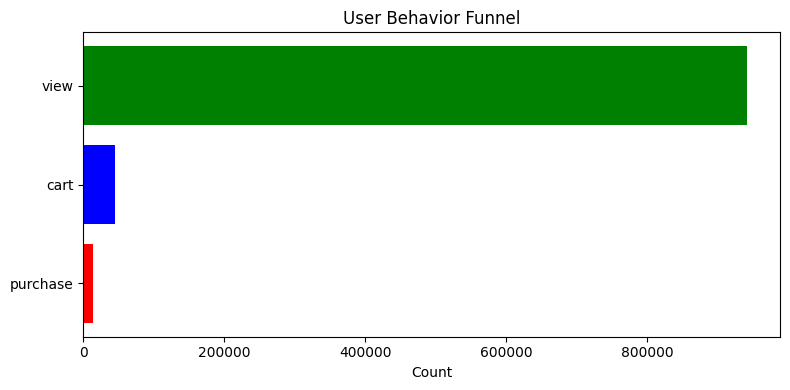

In [71]:
stages = ["view", "cart", "purchase"]
values = [941622, 45037, 13341]
colors = ["red", "blue", "green"]

fig, ax = plt.subplots(figsize=(8, 4))

ax.barh(stages[::-1], values[::-1], color=colors)

ax.set_title("User Behavior Funnel")
ax.set_xlabel("Count")

plt.tight_layout()
plt.savefig("funnel_chart.png", dpi=150)

plt.show()

In [86]:
conv_cart = values[1] / values[0]
conv_purchase = values[2] / values[1]

print(f"{conv_cart:.2%}")
print(f"{conv_purchase:.2%}")

65.59%
4.78%
29.62%


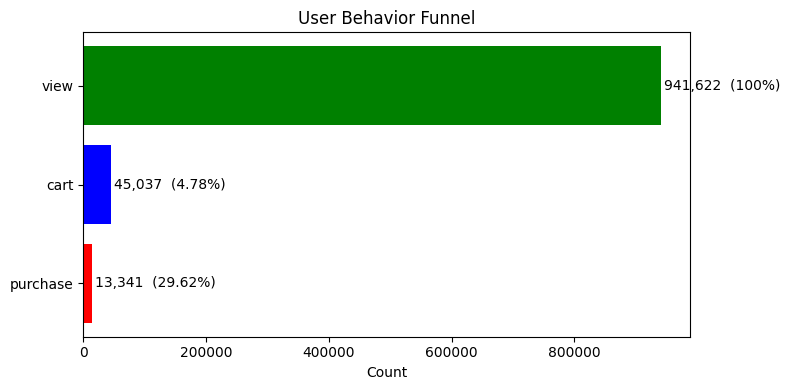

In [94]:
stages = ["view", "cart", "purchase"]
values = [941622, 45037, 13341]
colors = ["red", "blue", "green"]
conversions = ["100%", f"{conv_cart:.2%}",f"{conv_purchase:.2%}"]

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(stages[::-1], values[::-1], color=colors)

for i, (v, c) in enumerate(zip(values[::-1], conversions[::-1])):
    ax.text(v + 5000, i, f"{v:,}  ({c})", va="center")

ax.set_title("User Behavior Funnel")
ax.set_xlabel("Count")
plt.tight_layout()
plt.savefig("funnel_chart.png", dpi=150)

plt.show()

In [113]:
precision_list = [float(p) for p in precision_list]
recall_list = [float(r) for r in recall_list]
f1_list = [float(f) for f in f1_list]

print(k_values)
print(precision_list)
print(recall_list)
print(f1_list)

[3, 10, 20]
[0.04915254237288136, 0.027966101694915254, 0.019067796610169493]
[0.13983050847457626, 0.2669491525423729, 0.3593220338983051]
[0.07273694611233564, 0.050628287551139683, 0.03621386679826143]


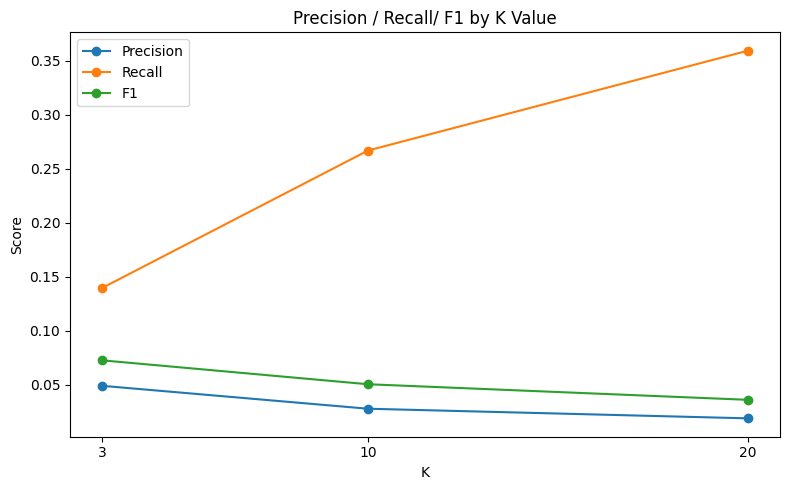

In [125]:
fig, ax = plt.subplots(figsize=(8,5))

ax.plot(k_values, precision_list, marker="o", label="Precision")
ax.plot(k_values, recall_list, marker="o", label="Recall")
ax.plot(k_values, f1_list, marker="o", label="F1")

ax.set_title("Precision / Recall/ F1 by K Value")
ax.set_xlabel("K")
ax.set_ylabel("Score")
ax.legend()
ax.set_xticks(k_values)

plt.tight_layout()
plt.savefig("Precision_recall_f1.png", dpi=150)
plt.show()

- Recall 隨 K 增加而上升：推薦越多商品，覆蓋到真正會買的機率越高
- Precision 隨 K 增加而下降：推薦越多商品，裡面的垃圾也越多
- F1 隨 K 增加而下降：代表 K=3 是這個模型的最佳平衡點